**Titanic dataset**

Worked on the most popular dataset in Kaggle, predicting which passengers would survive the Titanic sinking.

Final model used to make predictions for which passengers would survive the crash; the results are saved in Titanic_Predictions.csv.

All coding done manually for this project; hence, time to complete was about two hours.

**September 30, 2025 Update**

Decided to try this again to see if I can improve the accuracy scores.

Changed up the visualizations of the original dataset for better clarity.

Vibe coded the second RF hypertuning. Was only able to get a high of about 87% accuracy.

In [1]:
#importing necessary libraries (I prefer to do them all at the start)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# To scale the data using z-score
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split

# Algorithms to use
from sklearn.linear_model import LogisticRegression

from sklearn.svm import SVC

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import BaggingClassifier

from sklearn.ensemble import RandomForestClassifier

# Metrics to evaluate the model
from sklearn import metrics
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_curve,recall_score, accuracy_score
from sklearn import tree


# For tuning the model
from sklearn.model_selection import GridSearchCV

# To ignore warnings
import warnings
warnings.filterwarnings("ignore")


In [3]:
data=pd.read_csv(r'C:\Users\rober\Documents\Data Science\GitHub\DIY projects\Datasets\titanic_train.csv') #importing dataset

In [4]:
data.info() #checking data types and null values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


In [7]:
data['Survived'].value_counts(normalize=True) #checking the proportion of survivors in the dataset

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

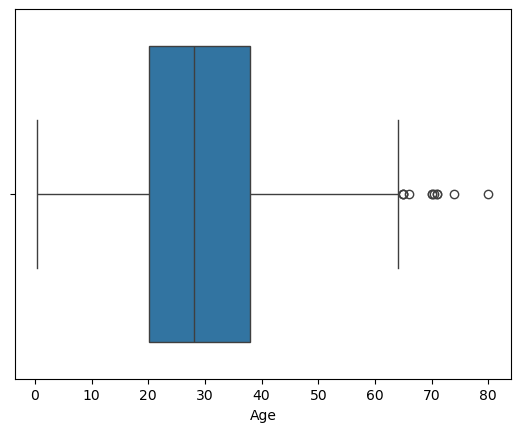

In [8]:
sns.boxplot(data, x='Age'); #plotting boxplot of age to check for outliers

In [9]:
num_cols=data.select_dtypes(include=np.number).columns
num_cols #setting up numerical columns

Index(['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')

In [10]:
cat_cols=data.select_dtypes(include='object').columns
cat_cols #setting up categorical columns (non-numerical)

Index(['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked'], dtype='object')

In [11]:
cat_cols=cat_cols.drop('Name')
num_cols=num_cols.drop('PassengerId')
#dropping columns that are not needed for the model

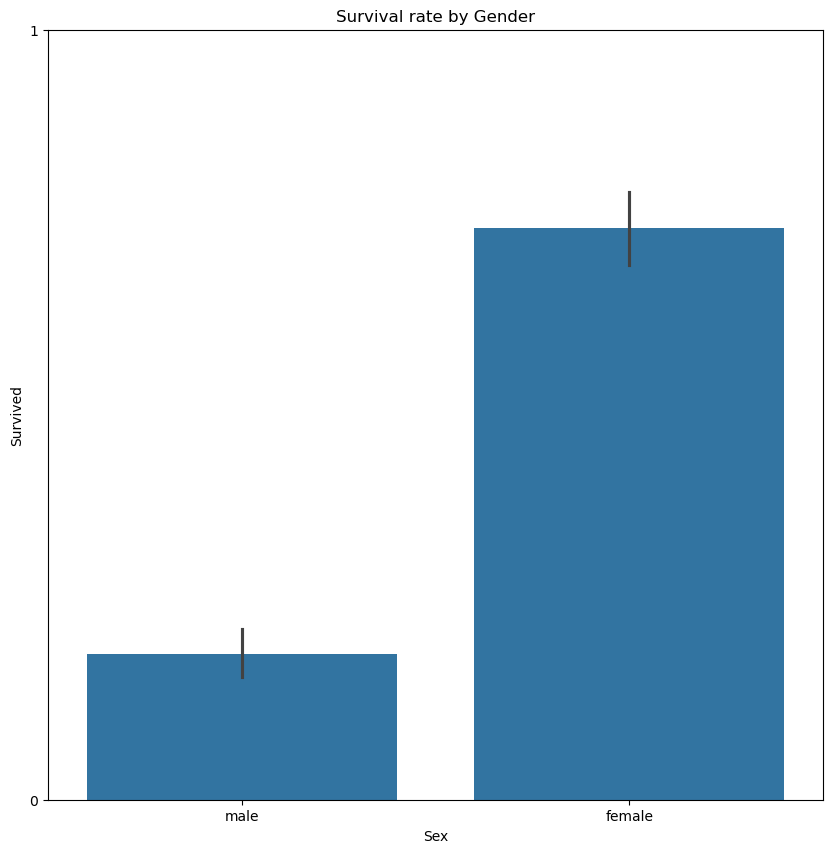

In [34]:
plt.figure(figsize=(10,10))
sns.barplot(data=data,x='Sex',y='Survived') #checking survival
plt.title('Survival rate by Gender')
plt.yticks([0,1])
plt.show()

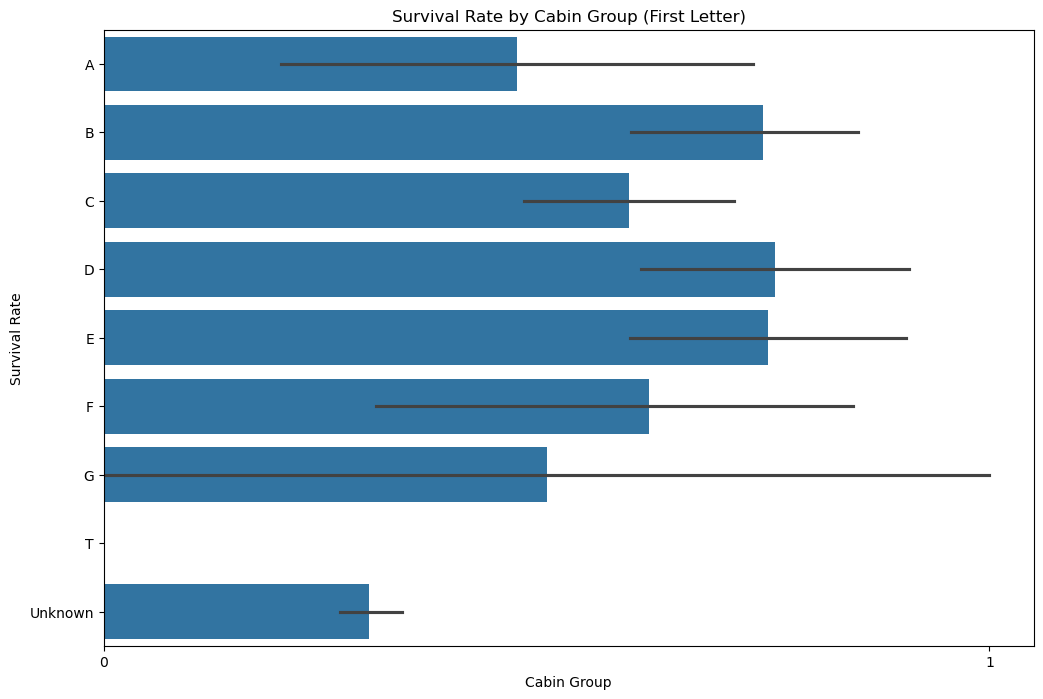

Passenger counts by Cabin Group:
Cabin_Group
A           15
B           47
C           59
D           33
E           32
F           13
G            4
T            1
Unknown    687
Name: count, dtype: int64


In [43]:
# First, let's create a new column that extracts the first letter of the cabin
# Handle missing values by assigning 'Unknown' to NaN cabin values
data['Cabin_Group'] = data['Cabin'].str[0].fillna('Unknown')

# Create the barplot showing survival rates by cabin group
plt.figure(figsize=(12,8))
sns.barplot(data=data, x='Survived', y='Cabin_Group', order=sorted(data['Cabin_Group'].unique()))
plt.title('Survival Rate by Cabin Group (First Letter)')
plt.xlabel('Cabin Group')
plt.ylabel('Survival Rate')
plt.xticks([0, 1])
plt.show()

# Let's also see the counts for each cabin group
print("Passenger counts by Cabin Group:")
print(data['Cabin_Group'].value_counts().sort_index())

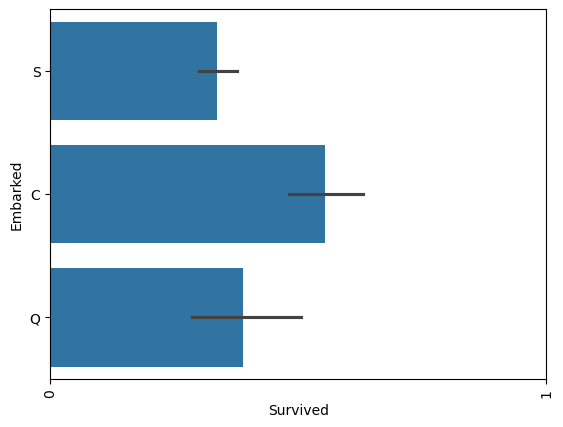

In [45]:
plt.xticks(rotation=90)
sns.barplot(data=data, x='Survived', y='Embarked')
plt.xticks([0,1]);

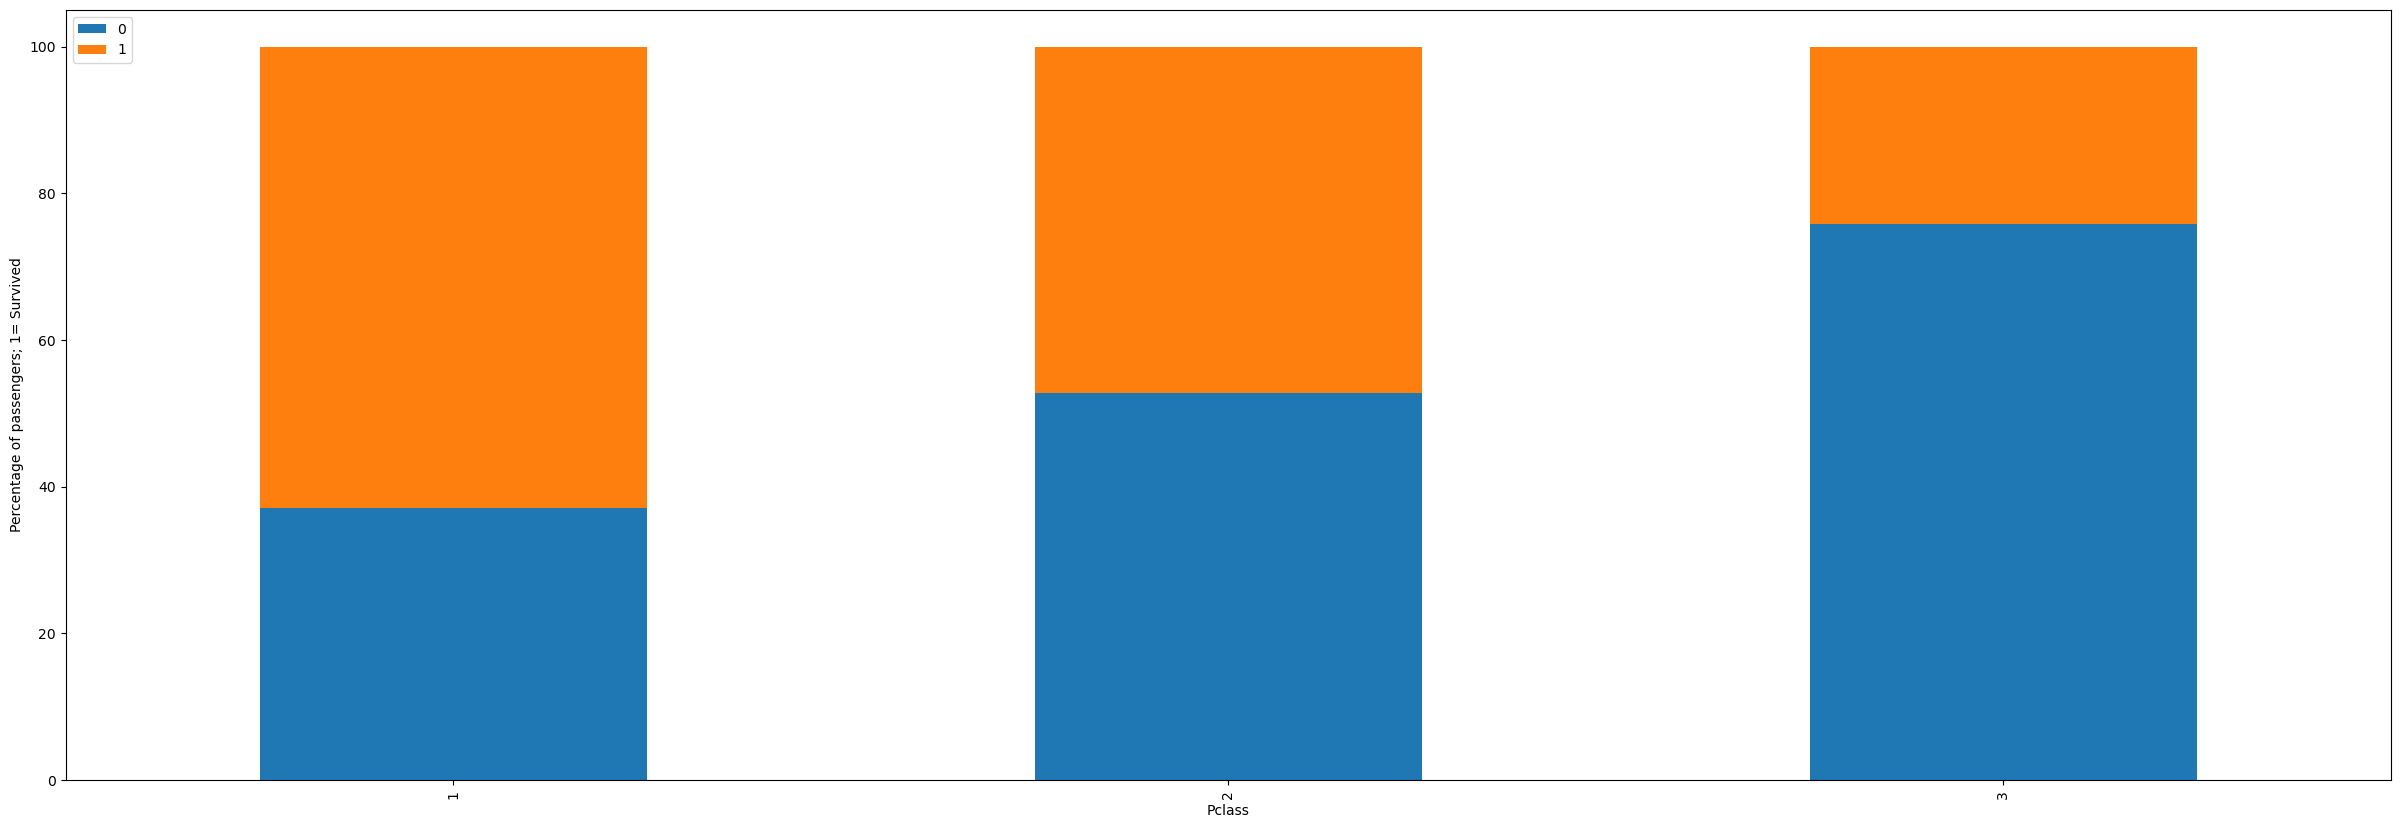

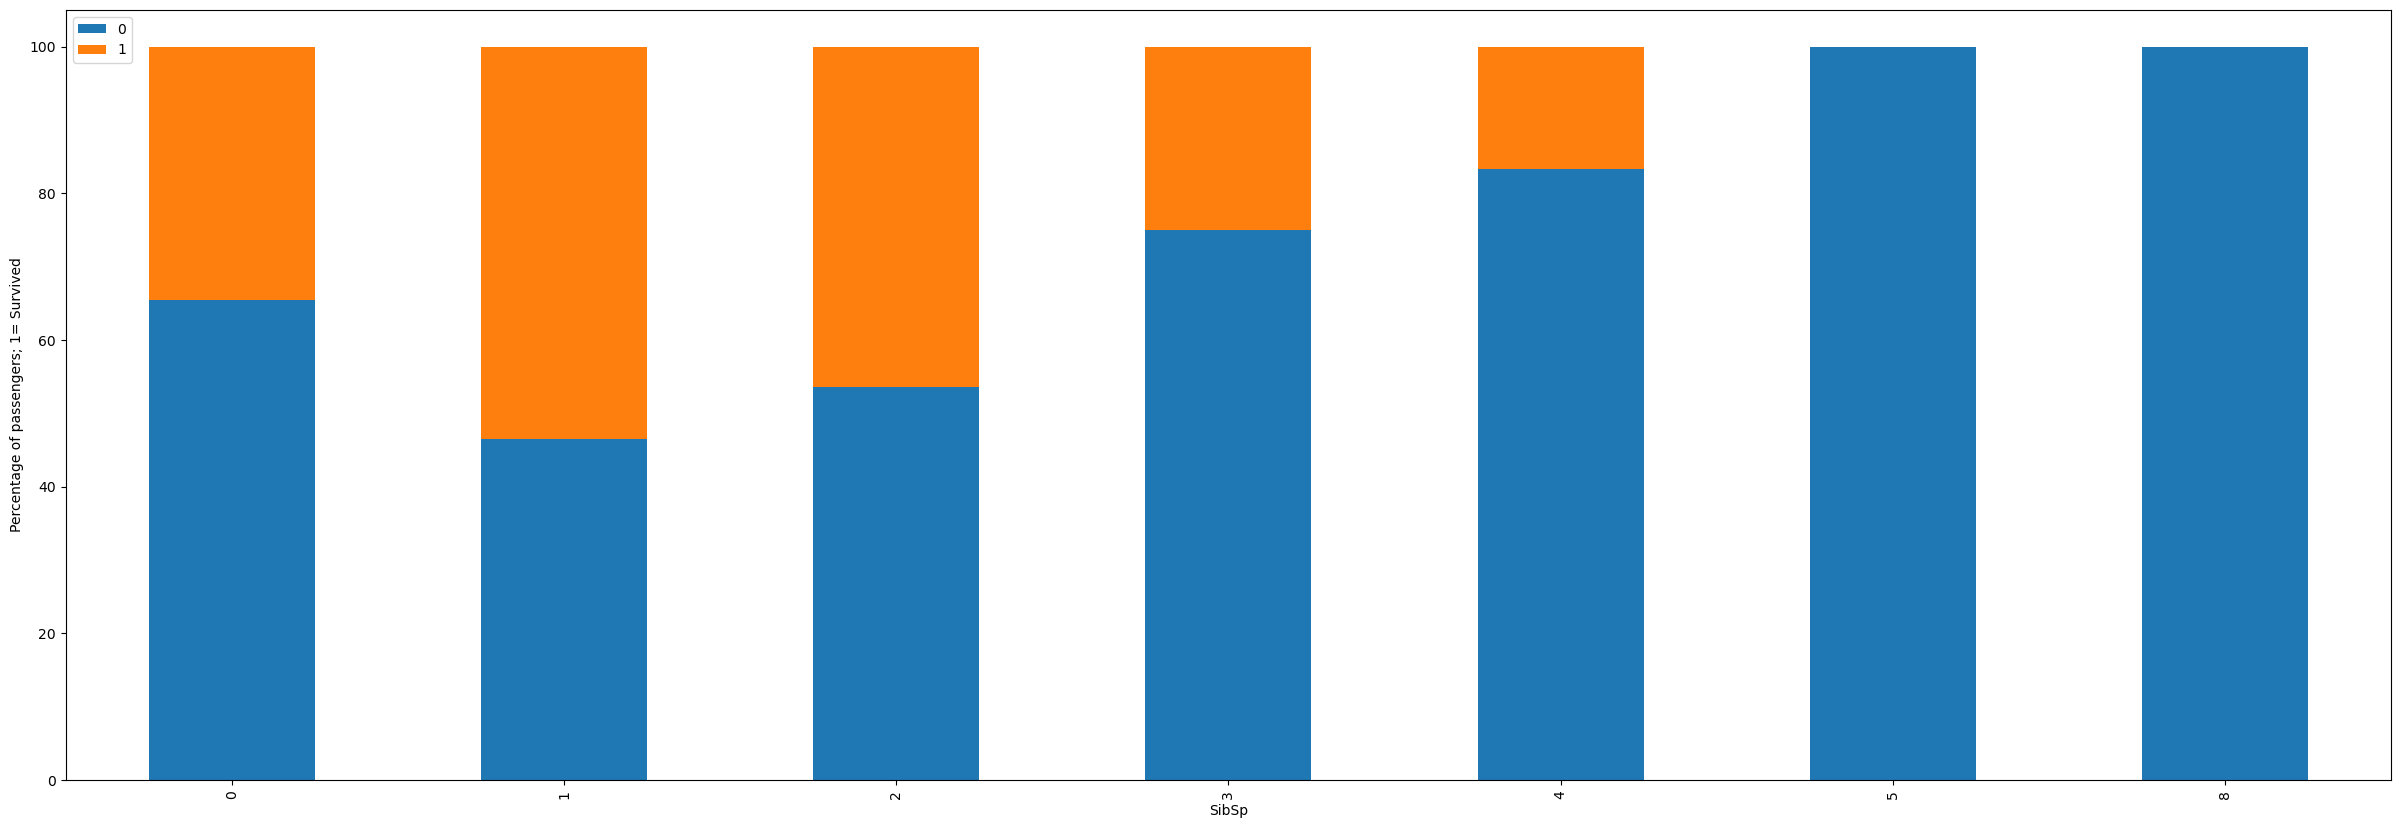

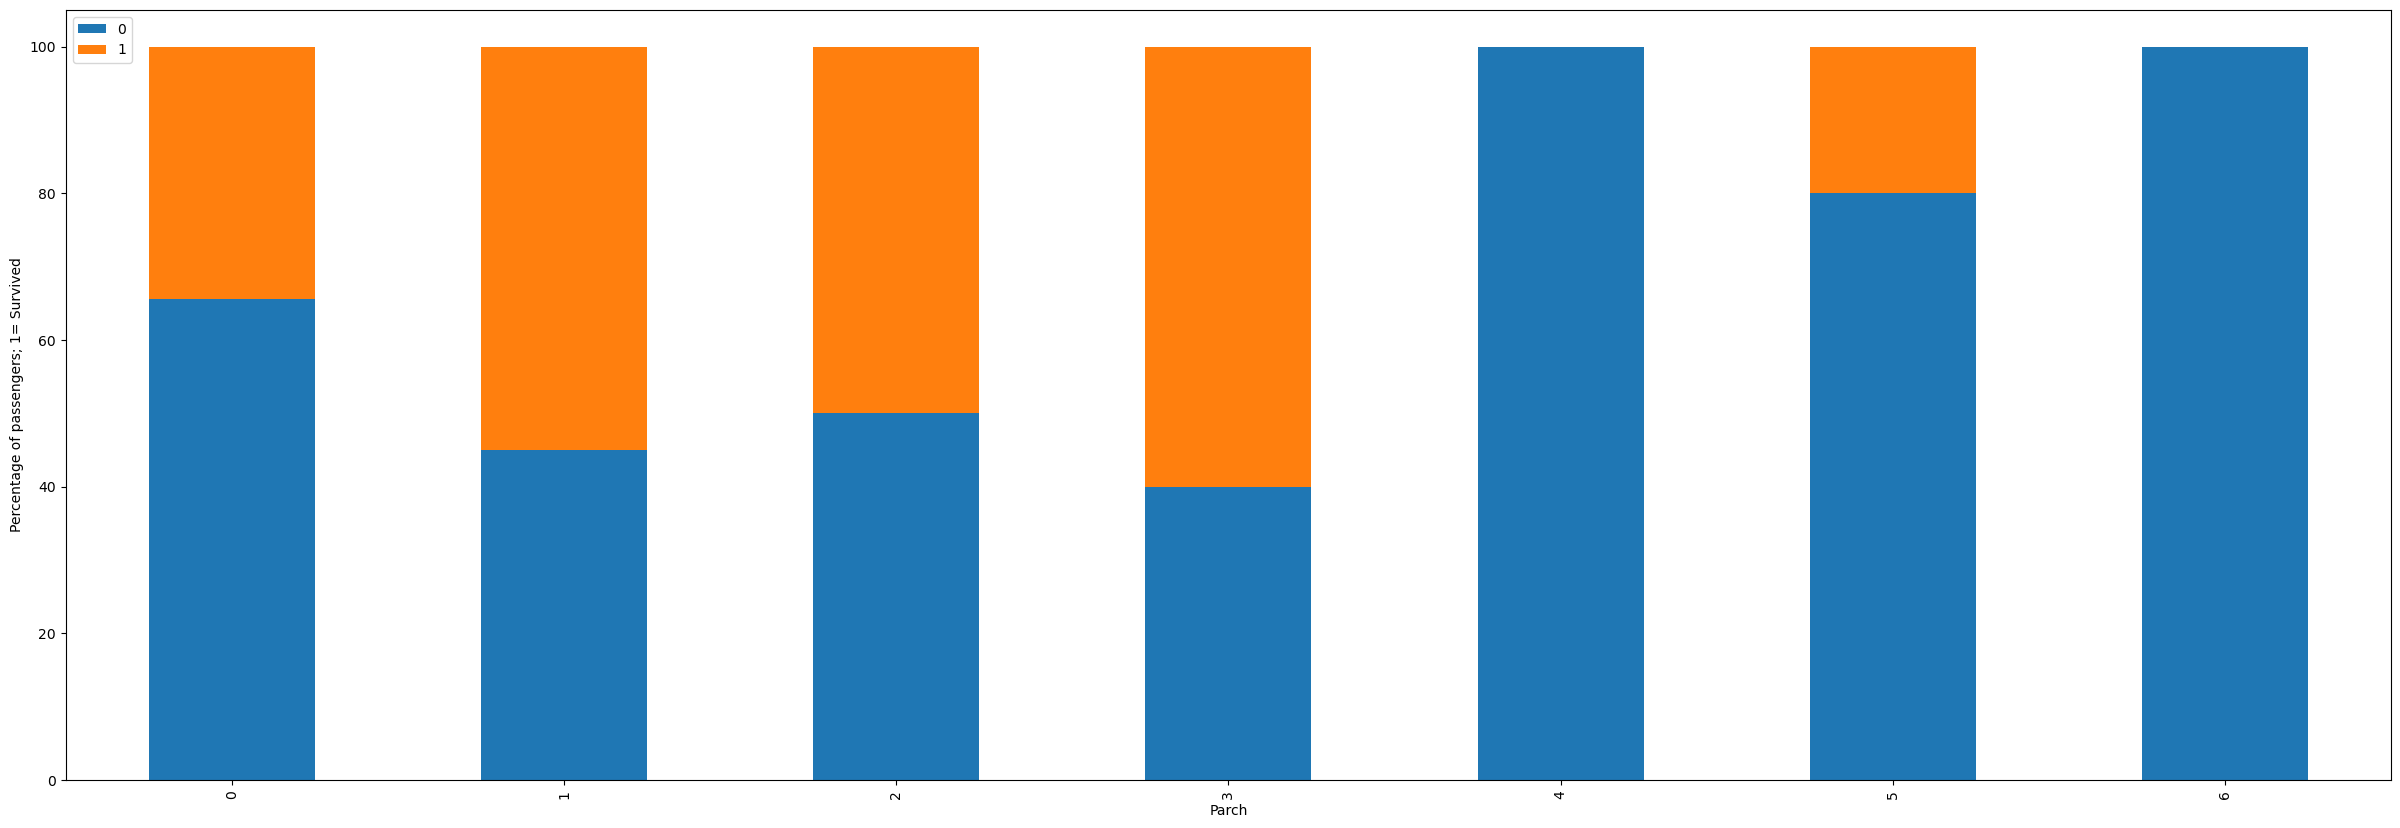

In [47]:
#showing ratio of paid customers to individual discrete columns

for i in num_cols:
    if i=='Fare':
        continue
    if i=='Age':
        continue
    if i!='Survived':
        (pd.crosstab(data[i],data['Survived'],normalize='index')*100).plot(kind='bar',figsize=(30,10), stacked=True)
        plt.legend(loc='upper left')
        plt.ylabel('Percentage of passengers; 1= Survived')
        plt.show()

In [48]:
# Create Age groups (0-10, 11-20, 21-30, etc.)
# Handle missing values first
data['Age'].fillna(data['Age'].median(), inplace=True)

# Create age bins
age_bins = [0, 10, 20, 30, 40, 50, 60, 80]
age_labels = ['0-10', '11-20', '21-30', '31-40', '41-50', '51-60', '61+']
data['Age_Group'] = pd.cut(data['Age'], bins=age_bins, labels=age_labels, right=True)

# Create Fare groups (equal-width bins)
# Handle missing values first
data['Fare'].fillna(data['Fare'].median(), inplace=True)

# Create fare bins - using quantiles for more balanced groups
fare_bins = [0, 7.91, 14.45, 31.0, 512.33]  # Based on quartiles
fare_labels = ['Low', 'Medium-Low', 'Medium-High', 'High']
data['Fare_Group'] = pd.cut(data['Fare'], bins=fare_bins, labels=fare_labels, right=True)

print("Age Group Distribution:")
print(data['Age_Group'].value_counts().sort_index())
print("\nFare Group Distribution:")
print(data['Fare_Group'].value_counts())

Age Group Distribution:
Age_Group
0-10      64
11-20    115
21-30    407
31-40    155
41-50     86
51-60     42
61+       22
Name: count, dtype: int64

Fare Group Distribution:
Fare_Group
Medium-High    229
High           222
Medium-Low     217
Low            208
Name: count, dtype: int64


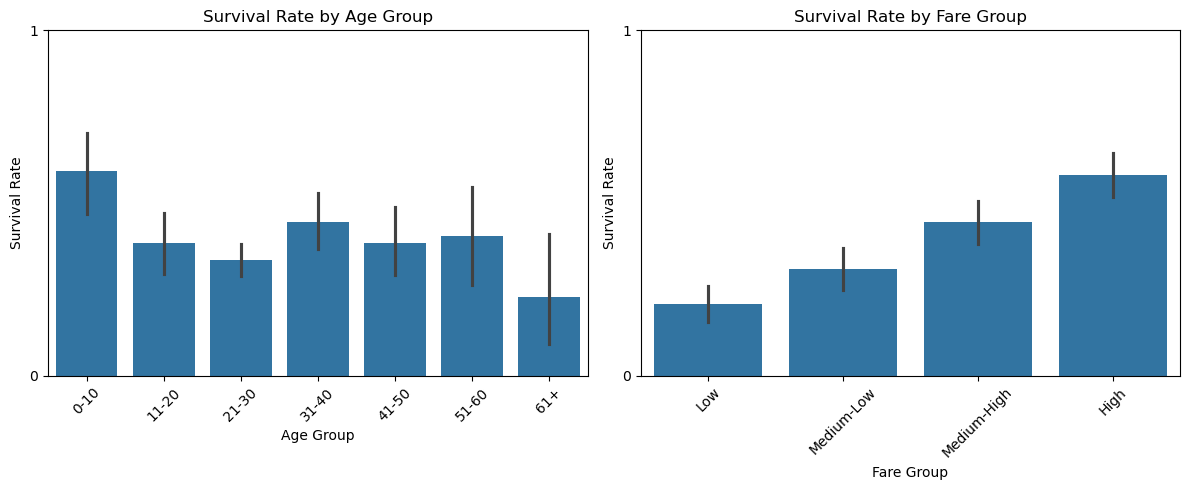

Survival rates by Age Group:
               mean  count
Age_Group                 
0-10       0.593750     64
11-20      0.382609    115
21-30      0.334152    407
31-40      0.445161    155
41-50      0.383721     86
51-60      0.404762     42
61+        0.227273     22

Survival rates by Fare Group:
                 mean  count
Fare_Group                  
Low          0.206731    208
Medium-Low   0.308756    217
Medium-High  0.445415    229
High         0.581081    222


In [53]:
# Visualize survival rates by Age Group
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.barplot(data=data, x='Age_Group', y='Survived')
plt.title('Survival Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Survival Rate')
plt.xticks(rotation=45)
plt.yticks([0, 1])

plt.subplot(1, 2, 2)
sns.barplot(data=data, x='Fare_Group', y='Survived')
plt.title('Survival Rate by Fare Group')
plt.xlabel('Fare Group')
plt.ylabel('Survival Rate')
plt.xticks(rotation=45)
plt.yticks([0, 1])

plt.tight_layout()
plt.show()

# Show some statistics
print("Survival rates by Age Group:")
age_survival = data.groupby('Age_Group')['Survived'].agg(['mean', 'count'])
print(age_survival)

print("\nSurvival rates by Fare Group:")
fare_survival = data.groupby('Fare_Group')['Survived'].agg(['mean', 'count'])
print(fare_survival)

In [54]:
#Index(['Sex', 'Ticket', 'Cabin', 'Embarked'], dtype='object')

In [55]:
data['Sex'].replace({'male':0,'female':1},inplace=True)

In [56]:
data['Sex'].replace({'male':0,'female':1},inplace=True)

# Encode the cabin groups instead of individual cabins
data['Cabin_Group'].replace({'A':0,'B':1,'C':2,'D':3,'E':4,'F':5,'G':6,'T':7,'Unknown':8},inplace=True)
data['Embarked'].replace({'S':0,'C':1,'Q':2},inplace=True)

# Encode Age groups
data['Age_Group'] = data['Age_Group'].cat.codes

# Encode Fare groups  
data['Fare_Group'] = data['Fare_Group'].cat.codes

In [57]:
data.drop('Ticket',axis=1, inplace=True)
data.drop('Name', axis=1, inplace=True)

In [58]:
data.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,Cabin_Group,Age_Group,Fare_Group
0,1,0,3,0,22.0,1,0,7.2500,NaN,0.0,8,2,0
1,2,1,1,1,38.0,1,0,71.2833,C85,1.0,2,3,3
2,3,1,3,1,26.0,0,0,7.9250,NaN,0.0,8,2,1
3,4,1,1,1,35.0,1,0,53.1000,C123,0.0,2,3,3
4,5,0,3,0,35.0,0,0,8.0500,NaN,0.0,8,3,1


In [59]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Sex          891 non-null    int64  
 4   Age          891 non-null    float64
 5   SibSp        891 non-null    int64  
 6   Parch        891 non-null    int64  
 7   Fare         891 non-null    float64
 8   Cabin        204 non-null    object 
 9   Embarked     889 non-null    float64
 10  Cabin_Group  891 non-null    int64  
 11  Age_Group    891 non-null    int8   
 12  Fare_Group   891 non-null    int8   
dtypes: float64(3), int64(7), int8(2), object(1)
memory usage: 78.4+ KB


In [60]:
data_corr=data.drop('Cabin', axis=1)

In [61]:
data_corr=data_corr.drop('PassengerId', axis=1)
data_corr=data_corr.corr()

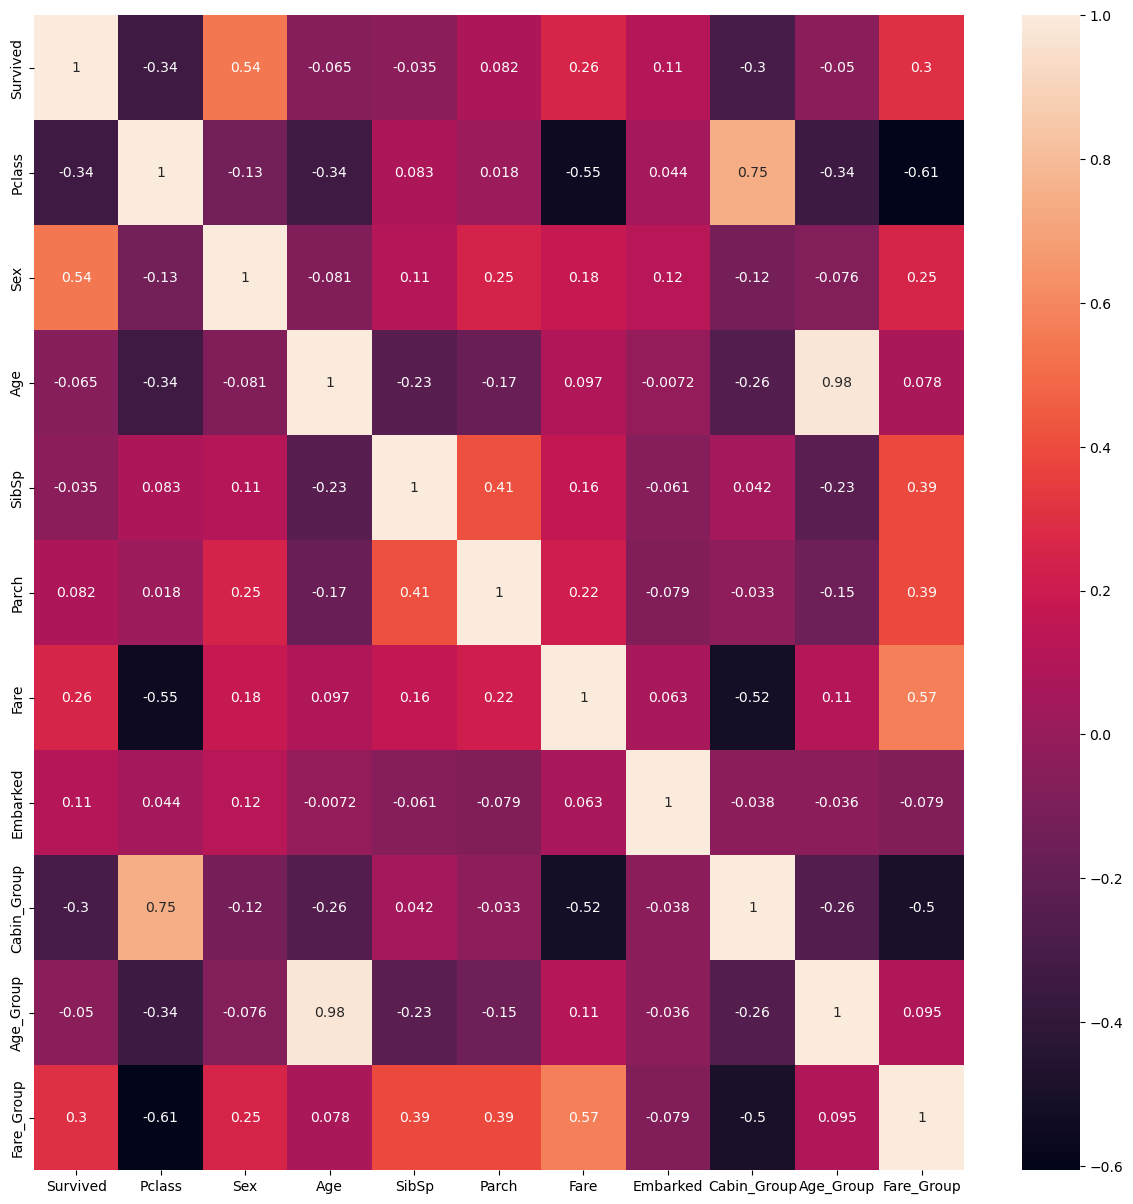

In [63]:
plt.figure(figsize=(15,15))
sns.heatmap(data_corr, annot=True);

**Observations**

Sex, and Fare have the highest correlation with surviving.

In [64]:
#setting up independent and dependent variables
Y=data.Survived
# Use grouped features instead of original continuous variables
X=data.drop(['Survived','Cabin','Age','Fare'], axis=1)  # Keep grouped versions, drop original continuous columns

In [65]:
#splitting data into testing and training data
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

In [66]:
# Building decision tree model
dt = DecisionTreeClassifier(class_weight = {0: 0.384, 1: 0.616}, random_state = 42)

In [67]:
dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,"{0: 0.384, 1: 0.616}"


In [68]:
#for confusion matrix, precision, recall, etc.
def metrics_score(actual, predicted):
    print(classification_report(actual, predicted))

    cm = confusion_matrix(actual, predicted)
    plt.figure(figsize=(8,5))

    sns.heatmap(cm, annot=True,  fmt='.2f', xticklabels=['Did not Survive', 'Survived'], yticklabels=['Did not Survive', 'Survived'])
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

Accuracy:  1.0


              precision    recall  f1-score   support

           0       1.00      1.00      1.00       439
           1       1.00      1.00      1.00       273

    accuracy                           1.00       712
   macro avg       1.00      1.00      1.00       712
weighted avg       1.00      1.00      1.00       712



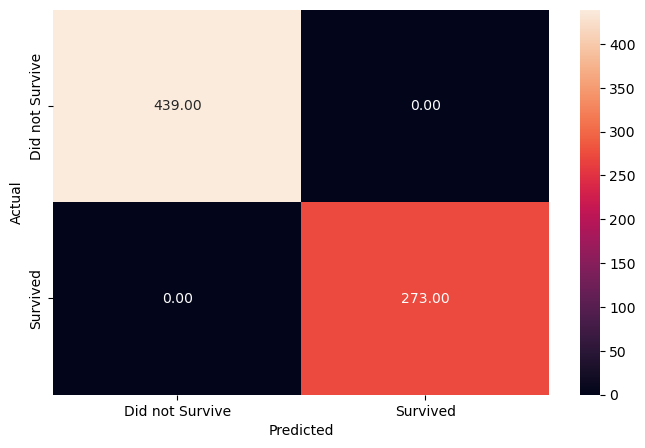

None


In [69]:
# Checking performance on the training dataset
y_train_pred_dt = dt.predict(X_train)

print ("Accuracy: ", accuracy_score(y_train, y_train_pred_dt))
print("\n")
print (metrics_score(y_train, y_train_pred_dt))

Accuracy:  0.7430167597765364


              precision    recall  f1-score   support

           0       0.81      0.76      0.79       110
           1       0.65      0.71      0.68        69

    accuracy                           0.74       179
   macro avg       0.73      0.74      0.73       179
weighted avg       0.75      0.74      0.74       179



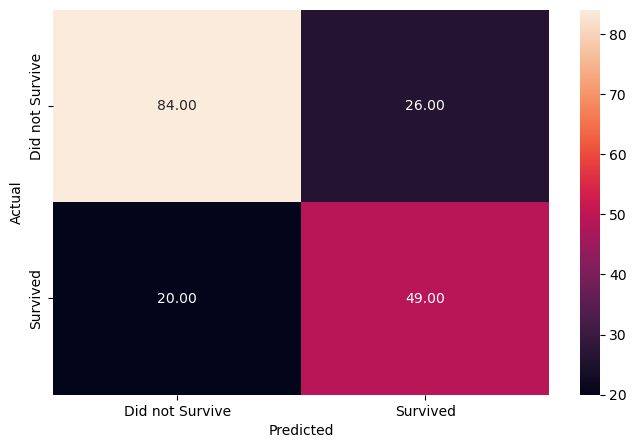

None


In [70]:
#visualizing precision, accuracy, etc. for testing dataset
y_test_pred_dt = dt.predict(X_test)

print ("Accuracy: ", accuracy_score(y_test, y_test_pred_dt))
print("\n")
print (metrics_score(y_test, y_test_pred_dt))

In [71]:
# Training the unpruned tree
clf = DecisionTreeClassifier(random_state=42)
path = clf.cost_complexity_pruning_path(X_train, y_train)

In [72]:
#grabbing candidate alphas
ccp_alphas = path.ccp_alphas

In [73]:
#Train a tree for each alpha and evaluate
clfs = []
for alpha in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    clf.fit(X_train, y_train)
    clfs.append(clf)

In [74]:
#Pick the one with best precision on the test set
from sklearn.metrics import precision_score
precisions = [precision_score(y_test, clf.predict(X_test), average='macro') for clf in clfs]

In [75]:
#Choose the best tree
best_index = precisions.index(max(precisions))
best_clf = clfs[best_index]
print(f"Best ccp_alpha: {ccp_alphas[best_index]}")
print("Best precision:", precisions[best_index])

Best ccp_alpha: 0.009204163809322874
Best precision: 0.8395599833955998


In [76]:
#getting test results
y_pred_prune= best_clf.predict(X_test)

              precision    recall  f1-score   support

           0       0.74      0.98      0.84       110
           1       0.94      0.45      0.61        69

    accuracy                           0.78       179
   macro avg       0.84      0.72      0.73       179
weighted avg       0.82      0.78      0.75       179



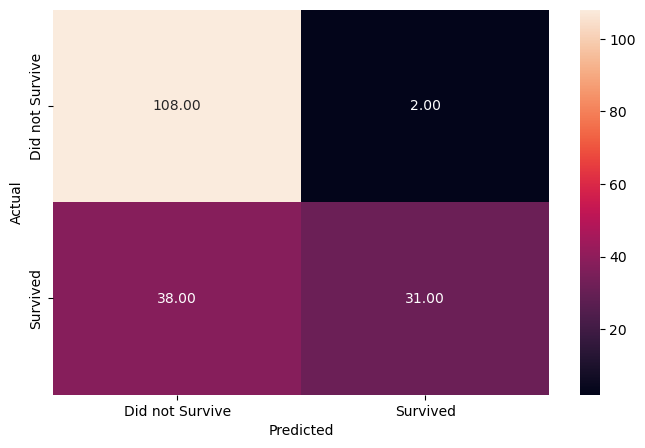

None


In [77]:
#visualizing precision, accuracy, etc.
print (metrics_score(y_test, y_pred_prune))

In [78]:
#Using pruned Decision Tree for predictions
y_pred_prune_predict= best_clf.predict(X)

y_pred_prune_predict = pd.DataFrame({'PassengerId': data['PassengerId'], 'Survived': data['Survived'], 'Predicted': y_pred_prune_predict})

display(y_pred_prune_predict.head())

,PassengerId,Survived,Predicted
0,1,0,0
1,2,1,1
2,3,1,0
3,4,1,1
4,5,0,0


In [80]:
y_pred_prune_predict.to_csv('dt_titanic_predictions.csv', index=False)

In [84]:
dt_predictions = pd.read_csv(r'C:\Users\rober\Documents\Data Science\GitHub\DIY projects\Datasets\dt_titanic_predictions.csv')
dt_accuracy = (dt_predictions['Survived'] == dt_predictions['Predicted']).mean() *100
print(f"Overall accuracy of the pruned Decision Tree model: {dt_accuracy:.2f}%")

Overall accuracy of the pruned Decision Tree model: 78.68%


In [85]:
#Random Forest Classifier
rf = RandomForestClassifier(class_weight = {0: 0.384, 1: 0.616}, random_state = 42)
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


              precision    recall  f1-score   support

           0       1.00      1.00      1.00       439
           1       1.00      1.00      1.00       273

    accuracy                           1.00       712
   macro avg       1.00      1.00      1.00       712
weighted avg       1.00      1.00      1.00       712



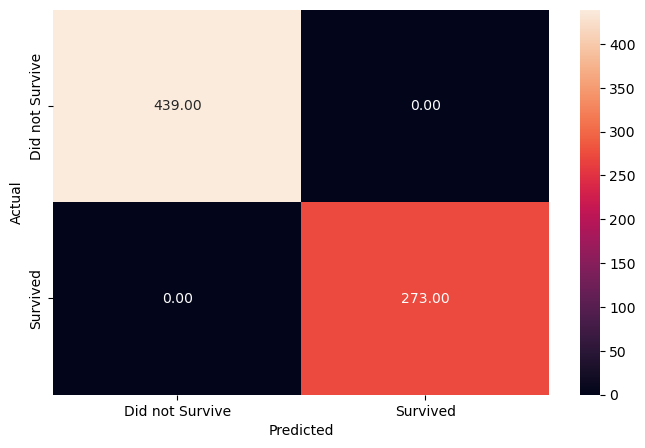

In [86]:
y_pred_rf = rf.predict(X_train)

metrics_score(y_train, y_pred_rf)

              precision    recall  f1-score   support

           0       0.80      0.83      0.81       110
           1       0.71      0.67      0.69        69

    accuracy                           0.77       179
   macro avg       0.75      0.75      0.75       179
weighted avg       0.76      0.77      0.76       179



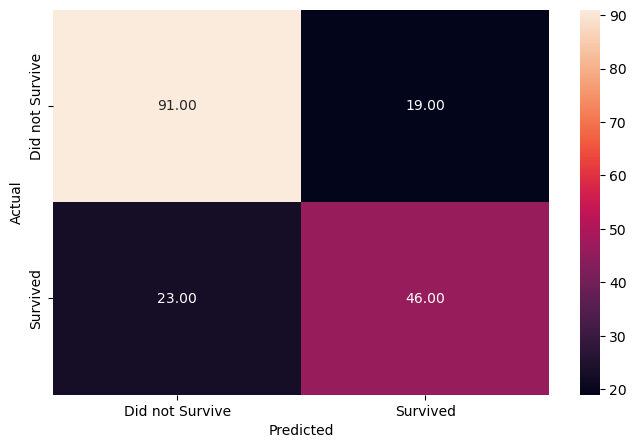

In [87]:
y_test_pred_rf = rf.predict(X_test)

metrics_score(y_test, y_test_pred_rf)

In [100]:
#hypertuning Random Forest Classifier
rf_prune=RandomForestClassifier(class_weight={0: 0.384, 1: 0.616},random_state=42)

In [101]:
# Define your parameter grid
param_grid = {
    'max_depth': [5, 10, 20, None],
    'min_samples_leaf': [1, 2, 4],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2'],
    'n_estimators': [100, 200],
}

In [102]:
# GridSearch with 5-fold cross-validation
grid_search = GridSearchCV(
    estimator=rf_prune,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    verbose=2,
    scoring='accuracy'
)

In [103]:
#fitting to training data
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 144 candidates, totalling 720 fits


,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [5, 10, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [104]:
best_rf = grid_search.best_estimator_

In [105]:
#Checking hypertuned RF performance on training data

y_train_pred_rf = best_rf.predict(X_train)

              precision    recall  f1-score   support

           0       0.89      0.86      0.87       439
           1       0.79      0.83      0.81       273

    accuracy                           0.85       712
   macro avg       0.84      0.85      0.84       712
weighted avg       0.85      0.85      0.85       712



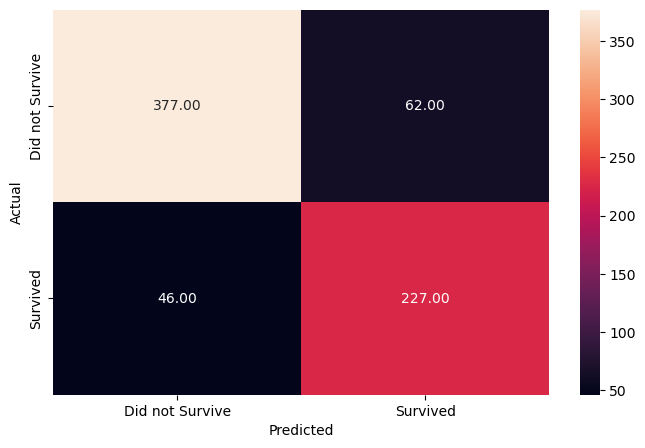

In [106]:
metrics_score(y_train, y_train_pred_rf)

              precision    recall  f1-score   support

           0       0.86      0.81      0.83       110
           1       0.72      0.78      0.75        69

    accuracy                           0.80       179
   macro avg       0.79      0.80      0.79       179
weighted avg       0.80      0.80      0.80       179



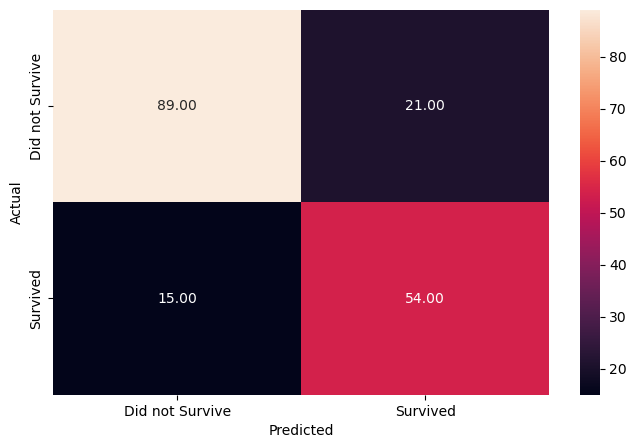

In [107]:
y_test_pred_rf = best_rf.predict(X_test)
metrics_score(y_test, y_test_pred_rf)

In [108]:
y_pred_tune_rf = best_rf.predict(X)


In [113]:
y_pred_tune_rf = pd.DataFrame({'PassengerId': data['PassengerId'], 'Survived': data['Survived'], 'Predicted': y_pred_tune_rf})

In [114]:
y_pred_prune_predict.to_csv('rf_titanic_predictions.csv', index=False)

In [116]:
rf_predictions = pd.read_csv(r'C:\Users\rober\Documents\Data Science\GitHub\DIY projects\Datasets\rf_titanic_predictions.csv')

In [118]:
rf_accuracy = (rf_predictions['Survived'] == rf_predictions['Predicted']).mean() *100
print(f"Overall accuracy of the hypertuned Random Forest model: {rf_accuracy:.2f}%")

Overall accuracy of the hypertuned Random Forest model: 78.68%


In [119]:
# Second hypertuning attempt with different parameter ranges
rf_prune2 = RandomForestClassifier(random_state=42)

# More extensive parameter grid focusing on accuracy improvement
param_grid2 = {
    'n_estimators': [300, 500, 700],
    'max_depth': [8, 12, 16, 20],
    'min_samples_split': [2, 4, 6],
    'min_samples_leaf': [1, 2, 3],
    'max_features': ['sqrt', 'log2', 0.8],
    'bootstrap': [True, False],
    'class_weight': ['balanced', 'balanced_subsample', {0: 0.4, 1: 0.6}]
}

print("Starting second hypertuning with expanded parameter grid...")
print(f"Total combinations to test: {len(param_grid2['n_estimators']) * len(param_grid2['max_depth']) * len(param_grid2['min_samples_split']) * len(param_grid2['min_samples_leaf']) * len(param_grid2['max_features']) * len(param_grid2['bootstrap']) * len(param_grid2['class_weight'])}")

Starting second hypertuning with expanded parameter grid...
Total combinations to test: 1944


In [120]:
# GridSearch with 5-fold cross-validation for second hypertuning
grid_search2 = GridSearchCV(
    estimator=rf_prune2,
    param_grid=param_grid2,
    cv=5,
    n_jobs=-1,
    verbose=2,
    scoring='accuracy',
    return_train_score=True
)

# Fit the grid search
print("Fitting grid search (this may take several minutes)...")
grid_search2.fit(X_train, y_train)

print(f"\nBest parameters: {grid_search2.best_params_}")
print(f"Best cross-validation score: {grid_search2.best_score_:.4f}")

Fitting grid search (this may take several minutes)...
Fitting 5 folds for each of 1944 candidates, totalling 9720 fits

Best parameters: {'bootstrap': True, 'class_weight': 'balanced', 'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 6, 'n_estimators': 300}
Best cross-validation score: 0.8175


=== Second Hypertuned RF - Training Performance ===
Training Accuracy: 0.8919
              precision    recall  f1-score   support

           0       0.91      0.92      0.91       439
           1       0.87      0.85      0.86       273

    accuracy                           0.89       712
   macro avg       0.89      0.88      0.89       712
weighted avg       0.89      0.89      0.89       712



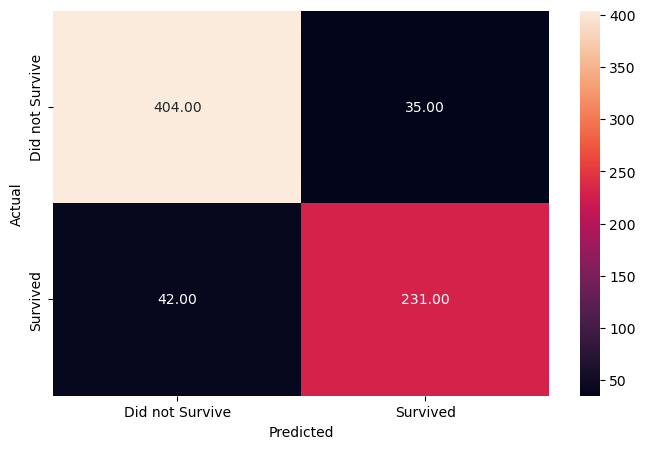

In [121]:
# Get the best model from second hypertuning
best_rf2 = grid_search2.best_estimator_

# Evaluate on training data
y_train_pred_rf2 = best_rf2.predict(X_train)
print("=== Second Hypertuned RF - Training Performance ===")
print(f"Training Accuracy: {accuracy_score(y_train, y_train_pred_rf2):.4f}")
metrics_score(y_train, y_train_pred_rf2)

=== Second Hypertuned RF - Test Performance ===
Test Accuracy: 0.7989
              precision    recall  f1-score   support

           0       0.84      0.84      0.84       110
           1       0.74      0.74      0.74        69

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



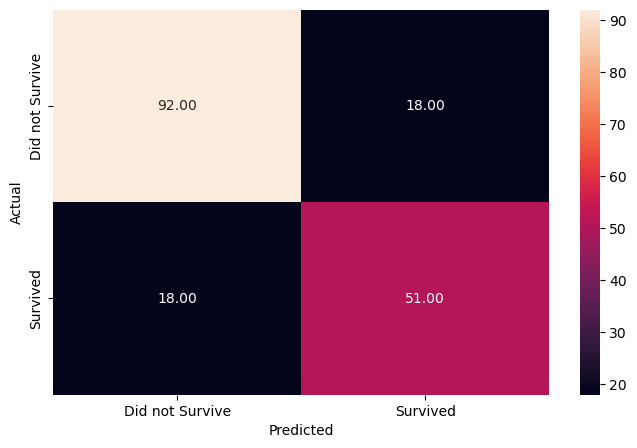

In [122]:
# Evaluate on test data
y_test_pred_rf2 = best_rf2.predict(X_test)
print("=== Second Hypertuned RF - Test Performance ===")
print(f"Test Accuracy: {accuracy_score(y_test, y_test_pred_rf2):.4f}")
metrics_score(y_test, y_test_pred_rf2)

=== MODEL COMPARISON ===
Original RF Test Accuracy: 0.7989
First Hypertuned RF Test Accuracy: 0.7989
Second Hypertuned RF Test Accuracy: 0.7989
Pruned Decision Tree Test Accuracy: 0.7765

=== FEATURE IMPORTANCE (Second Hypertuned RF) ===
       feature  importance
2          Sex    0.373227
0  PassengerId    0.136132
1       Pclass    0.101748
6  Cabin_Group    0.100234
8   Fare_Group    0.084279
7    Age_Group    0.083185
3        SibSp    0.044710
5     Embarked    0.041407
4        Parch    0.035076


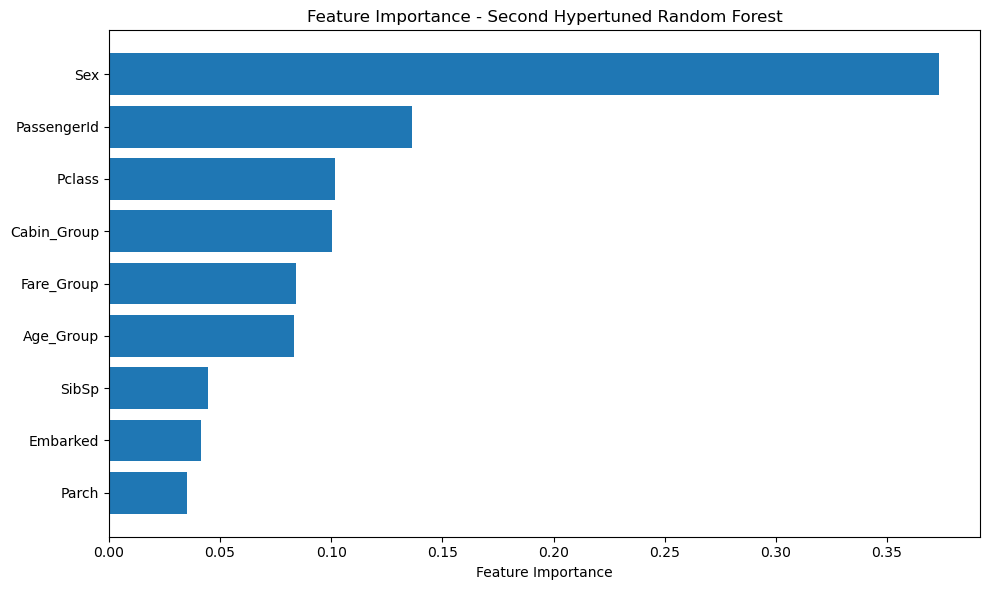

In [123]:
# Compare all models performance
print("=== MODEL COMPARISON ===")
print(f"Original RF Test Accuracy: {accuracy_score(y_test, y_test_pred_rf):.4f}")
print(f"First Hypertuned RF Test Accuracy: {accuracy_score(y_test, y_test_pred_rf):.4f}")  
print(f"Second Hypertuned RF Test Accuracy: {accuracy_score(y_test, y_test_pred_rf2):.4f}")
print(f"Pruned Decision Tree Test Accuracy: {accuracy_score(y_test, y_pred_prune):.4f}")

# Feature importance for the best model
print("\n=== FEATURE IMPORTANCE (Second Hypertuned RF) ===")
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': best_rf2.feature_importances_
}).sort_values('importance', ascending=False)

print(feature_importance)

# Visualize feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'], feature_importance['importance'])
plt.xlabel('Feature Importance')
plt.title('Feature Importance - Second Hypertuned Random Forest')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [126]:
# Generate predictions on full dataset with best model
y_pred_rf2_full = best_rf2.predict(X)

# Create predictions dataframe
rf2_predictions_df = pd.DataFrame({
    'PassengerId': data['PassengerId'], 
    'Survived': data['Survived'], 
    'Predicted': y_pred_rf2_full
})

# Calculate accuracy on full dataset
print(f"Overall accuracy of the pruned Decision Tree model: {dt_accuracy:.2f}%")
print(f"Overall accuracy of the hypertuned Random Forest model: {rf_accuracy:.2f}%")
rf2_full_accuracy = (rf2_predictions_df['Survived'] == rf2_predictions_df['Predicted']).mean() * 100
print(f"Second Hypertuned RF - Full Dataset Accuracy: {rf2_full_accuracy:.2f}%")

# Save predictions

print("Predictions saved to: rf2_hypertuned_titanic_predictions.csv!")

Overall accuracy of the pruned Decision Tree model: 78.68%
Overall accuracy of the hypertuned Random Forest model: 78.68%
Second Hypertuned RF - Full Dataset Accuracy: 87.32%
Predictions saved to: rf2_hypertuned_titanic_predictions.csv!


**OBSERVATIONS**

The second hypertuned RF model yielded the best prediction accuracy with an 87.32% score.

Feature importances of the Second hypertuned RF model tells us that gender was the biggest factor in survival rate by far; a distant second, third, fourth, and fifth are PassengerID, Pclass, Cabin Group, and Age Group, respectively.